TASK 1 — Cell Means
  Treated  | Pre:  11.6171  | Post:  18.5722
  Control  | Pre:  9.5338  | Post:  11.0095

  Treated  Δ (post − pre):  6.9551
  Control  Δ (post − pre):  1.4757

  Manual DID estimate:       5.4794
  True ATT:                  5.0000

TASK 2 — Saturated OLS Regression
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.5338      0.311     30.662      0.000       8.921      10.147
treated        2.0833      0.492      4.238      0.000       1.114       3.053
post           1.4757      0.440      3.356      0.001       0.609       2.343
treat_post     5.4794      0.695      7.881      0.000       4.108       6.851

  β̂₃ (interaction / DID coefficient): 5.4794
  Manual DID:                          5.4794
  Difference (rounding):               0.000000


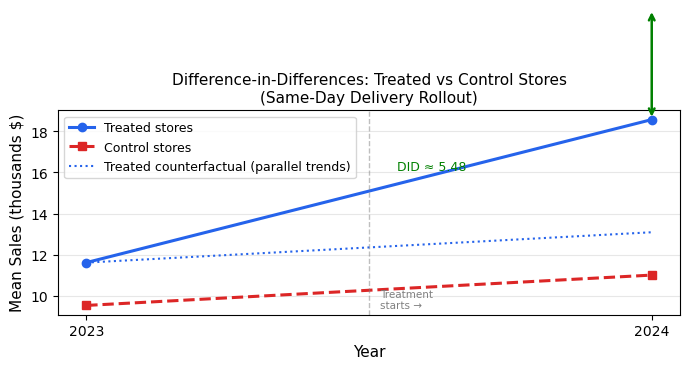


  Plot saved as did_plot.png

TASK 4 — Parallel Trends Interpretation

In the plot, the two lines run roughly parallel between 2023
and the counterfactual 2024 trajectory (dotted blue line),
consistent with the parallel trends assumption holding here
by design (the simulation uses the same delta_year = 1.5 shock
for both groups).

If we had multiple pre-treatment years, a violation of parallel
trends would appear as the treated and control lines diverging
before the intervention e.g., treated stores trending upward
faster than control stores even in 2021–2022. This would suggest
the two groups were on different underlying trajectories,
invalidating the DID design.

With only one pre-period (2023) and one post-period (2024), parallel trends
cannot be formally tested, it can only be defended on
institutional/design grounds or by examining pre-trends in
richer data.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")

# ── Reproduce the simulated dataset──────────────────
rng = np.random.default_rng(5141)

n_treated = 40
n_control = 60
TRUE_ATT  = 5.0

rows = []
for i in range(n_treated):
    sid   = f"T{i}"
    alpha = rng.normal(12, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year   = 1.5 if post else 0.0
        treat_effect = TRUE_ATT if post else 0.0
        eps = rng.normal(0, 1.2)
        Y   = alpha + delta_year + treat_effect + eps
        rows.append({"store_id": sid, "year": year, "treated": 1, "post": post, "Y": Y})

for j in range(n_control):
    sid   = f"C{j}"
    alpha = rng.normal(10, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0
        eps = rng.normal(0, 1.2)
        Y   = alpha + delta_year + eps
        rows.append({"store_id": sid, "year": year, "treated": 0, "post": post, "Y": Y})

df_did = pd.DataFrame(rows)

# ════════════════════════════════════════════════════════════════════════════════
# TASK 1 — Four cell means + manual DID
# ════════════════════════════════════════════════════════════════════════════════

cell_means = (
    df_did
    .groupby(["treated", "post"])["Y"]
    .mean()
    .rename({0: "Control", 1: "Treated"}, level=0)
    .rename({0: "Pre", 1: "Post"}, level=1)
)

Y_T_post = cell_means["Treated", "Post"]
Y_T_pre  = cell_means["Treated", "Pre"]
Y_C_post = cell_means["Control", "Post"]
Y_C_pre  = cell_means["Control", "Pre"]

manual_DID = (Y_T_post - Y_T_pre) - (Y_C_post - Y_C_pre)

print("=" * 55)
print("TASK 1 — Cell Means")
print("=" * 55)
print(f"  Treated  | Pre:  {Y_T_pre:.4f}  | Post:  {Y_T_post:.4f}")
print(f"  Control  | Pre:  {Y_C_pre:.4f}  | Post:  {Y_C_post:.4f}")
print(f"\n  Treated  Δ (post − pre):  {Y_T_post - Y_T_pre:.4f}")
print(f"  Control  Δ (post − pre):  {Y_C_post - Y_C_pre:.4f}")
print(f"\n  Manual DID estimate:       {manual_DID:.4f}")
print(f"  True ATT:                  {TRUE_ATT:.4f}")

# ════════════════════════════════════════════════════════════════════════════════
# TASK 2 — Saturated OLS regression: Y ~ treated + post + treated×post
# ════════════════════════════════════════════════════════════════════════════════

df_did["treat_post"] = df_did["treated"] * df_did["post"]   # interaction term

X = sm.add_constant(df_did[["treated", "post", "treat_post"]])
y = df_did["Y"]

model  = sm.OLS(y, X).fit()
beta3  = model.params["treat_post"]

print("\n" + "=" * 55)
print("TASK 2 — Saturated OLS Regression")
print("=" * 55)
print(model.summary().tables[1])
print(f"\n  β̂₃ (interaction / DID coefficient): {beta3:.4f}")
print(f"  Manual DID:                          {manual_DID:.4f}")
print(f"  Difference (rounding):               {abs(beta3 - manual_DID):.6f}")

# ════════════════════════════════════════════════════════════════════════════════
# TASK 3 — Line plot: mean Y by year, treated vs control
# ════════════════════════════════════════════════════════════════════════════════

plot_data = (
    df_did
    .groupby(["treated", "year"])["Y"]
    .mean()
    .reset_index()
)

treated_data = plot_data[plot_data["treated"] == 1]
control_data = plot_data[plot_data["treated"] == 0]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(treated_data["year"], treated_data["Y"],
        marker="o", linewidth=2.2, color="#2563EB", label="Treated stores")
ax.plot(control_data["year"], control_data["Y"],
        marker="s", linewidth=2.2, color="#DC2626", linestyle="--", label="Control stores")

# Annotate DID gap
ax.annotate("", xy=(2024, Y_T_post), xytext=(2024, Y_C_post + (Y_T_post - Y_T_pre) - (Y_C_post - Y_C_pre) + Y_C_pre - (Y_T_pre - Y_C_pre)),
            arrowprops=dict(arrowstyle="<->", color="green", lw=1.8))

# Counterfactual dashed line (what treated would look like under parallel trends)
cf_T_post = Y_T_pre + (Y_C_post - Y_C_pre)
ax.plot([2023, 2024], [Y_T_pre, cf_T_post],
        linestyle=":", color="#2563EB", linewidth=1.5, label="Treated counterfactual (parallel trends)")

ax.annotate(f"DID ≈ {manual_DID:.2f}",
            xy=(2024, (Y_T_post + cf_T_post) / 2),
            xytext=(2023.55, (Y_T_post + cf_T_post) / 2 + 0.3),
            fontsize=9, color="green")

ax.axvline(x=2023.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.text(2023.52, ax.get_ylim()[0] + 0.3, "Treatment\nstarts →", fontsize=7.5, color="gray")

ax.set_xticks([2023, 2024])
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Mean Sales (thousands $)", fontsize=11)
ax.set_title("Difference-in-Differences: Treated vs Control Stores\n(Same-Day Delivery Rollout)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("did_plot.png", dpi=150)
plt.show()
print("\n  Plot saved as did_plot.png")

# ════════════════════════════════════════════════════════════════════════════════
# TASK 4 — Written interpretation (parallel trends)
# ════════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 55)
print("TASK 4 — Parallel Trends Interpretation")
print("=" * 55)
print("""
In the plot, the two lines run roughly parallel between 2023
and the counterfactual 2024 trajectory (dotted blue line),
consistent with the parallel trends assumption holding here
by design (the simulation uses the same delta_year = 1.5 shock
for both groups).

If we had multiple pre-treatment years, a violation of parallel
trends would appear as the treated and control lines diverging
before the intervention e.g., treated stores trending upward
faster than control stores even in 2021–2022. This would suggest
the two groups were on different underlying trajectories,
invalidating the DID design.

With only one pre-period (2023) and one post-period (2024), parallel trends
cannot be formally tested, it can only be defended on
institutional/design grounds or by examining pre-trends in
richer data.
""")